## Plot mean of each cluster, for all clusters: Omega500
Fig 4

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from matplotlib import rcParams
import matplotlib
import ast

ERROR 1: PROJ: proj_create_from_database: Cannot find proj.db


In [2]:
rcParams['font.size'] = 20

In [3]:
#output file location
input_table_loc = '/div/nac/users/zofias/plots/XXN/prect_6_clim/single'
out_plots = '/div/nac/users/zofias/plots/XXN/paper_plots'

input_fileloc = '/div/no-backup-nac/users/zofias/CESM2-LENS/weather_data/7cluster_background'

group_label = '7_cluster_events'

var_name='OMEGA500'

# %%
# select region by changing region_label
region_label = 'NO_ext' #sys.argv[3] #'EU' # 'SA' 'EA' 'NA' 'EU'

regions = {'SA': [5,35,65,95],
           'EA' : [20,53,95,133],
           'NA' : [25,70,-150,-45],
           'EU' : [35,70,-20,45],
           'NO' : [53,72,0,32],
           'NO_ext': [50,75,-25,32]}

#selects lat lon bounds for region
lat_min, lat_max, lon_min, lon_max = regions[region_label]


In [4]:
locs_dataframe = pd.read_csv(f'{input_table_loc}/grouped_events_table.csv',index_col=0)

In [5]:
#extract member columns from filename
locs_dataframe['member_ind'] = pd.to_numeric(locs_dataframe['ens_member'].str[1:]) - 1

# read in disctionary of mapping from ensemble index to label
with open('/div/nac/users/zofias/XXN/ens_member_labs_dict.txt', 'r') as file:
    test = file.read()
    ens_dict = ast.literal_eval(test)

# map member index to label
locs_dataframe['member_lab'] = locs_dataframe['member_ind'].map(ens_dict)

#make column with correct dacade lab for file download
year_labs = ['20150101-20241231.nc','20250101-20341231.nc','20350101-20441231.nc','20450101-20541231.nc','20550101-20641231.nc','20650101-20741231.nc','20750101-20841231.nc','20850101-20941231.nc','20950101-21001231.nc']
bins = [2015, 2024, 2034, 2044, 2054, 2064, 2074, 2084, 2094,2101]
labels = year_labs
locs_dataframe['decade_lab'] = pd.cut(locs_dataframe.year, bins, labels = labels,include_lowest = True)

# make column with precip filename
locs_dataframe['lensfile'] = locs_dataframe.apply(lambda x: f"b.e21.BSSP370smbb.f09_g17.LE2-{x.member_lab}.cam.h1.{var_name}.{x.decade_lab}", axis=1)

In [6]:
#define dates for selecting data (14 days before up to 3 days after)
locs_dataframe['start_date'] = (pd.to_datetime(locs_dataframe['date']) - pd.to_timedelta(14,'d')).dt.strftime("%Y-%m-%d") 
locs_dataframe['end_date'] = (pd.to_datetime(locs_dataframe['date']) + pd.to_timedelta(3,'d')).dt.strftime("%Y-%m-%d")

In [7]:
#make lat and lon bins over select region (for selecting 9 gridboxes for each event)
# got event lat and lons from CESM2LENS nc file, lats have loads of decimals so rounded to 2dp here (same as in selection below)
lon_bins = [-25.,-23.75,-22.5,-21.25,-20.,-18.75,-17.5,-16.25,-15.,-13.75,-12.5,-11.25,-10.,-8.75,-7.5,-6.25,-5.,-3.75,-2.5 ,-1.25,0.,1.25,2.5,3.75,5.,6.25,7.5,8.75,10.,11.25,12.5,13.75,15.,16.25,17.5,18.75,20.,21.25,22.5,23.75,25.,26.25,27.5,28.75,30.,31.25]
locs_dataframe['lon_bin'] = pd.cut(locs_dataframe.lon, lon_bins, labels = lon_bins[:-1],include_lowest = True)
locs_dataframe['lon_min'] = locs_dataframe.lon_bin.apply(lambda x: x - 1.25)
locs_dataframe['lon_max'] = locs_dataframe.lon_bin.apply(lambda x: x + 1.25)

lat_bins = [49.48,  50.42,  51.36,  52.3 ,
        53.25,  54.19,  55.13,  56.07,  57.02,  57.96,  58.9 ,  59.84,
        60.79,  61.73,  62.67,  63.61,  64.55,  65.5 ,  66.44,  67.38,
        68.32,  69.27,  70.21,  71.15,  72.09,  73.04,  73.98,  74.92,
        75.86,  76.81,  77.75,  78.69,  79.63] #one extra on either end for making min and max

locs_dataframe['lat_bin'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[1:-2],include_lowest = True)
locs_dataframe['lat_min'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[0:-3],include_lowest = True)
locs_dataframe['lat_max'] = pd.cut(locs_dataframe.lat, lat_bins[1:-1],labels=lat_bins[2:-1],include_lowest = True)

In [8]:
# build concatenated dataset for each cluster
def load_cluster_events(cluster_df):
    event_datasets = []

    for i, row in cluster_df.reset_index(drop=True).iterrows():
        print(f"Processing {i+1} of {len(cluster_df)}")
        #print(row["start_date"])

        ds = xr.open_dataset(f"{input_fileloc}/{row['lensfile']}",
                             decode_times=True).sel(time=slice(row["start_date"], row["end_date"]))
        
        ds = ds.drop_vars("time_bnds", errors="ignore")

        #reset lon coord
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby("lon")
        #select region
        ds = ds.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

        #reindex time to be -14 to 3 for all events (some have 17 time steps, some have 18)
        n = ds.sizes["time"]                       # can be 17 or 18
        ds = ds.assign_coords(time=np.arange(-14, -14 + n))
        ds = ds.reindex(time=np.arange(-14, 4)) 

        event_datasets.append(ds[{var_name}])

    # member = event index within this cluster
    return xr.concat(event_datasets, dim="member")

In [9]:
locs_dataframe[locs_dataframe["group"] == 0][:8]

,filename,date,lat,lon,sigma,ens_member,type,group,pd_time,month,...,decade_lab,lensfile,start_date,end_date,lon_bin,lon_min,lon_max,lat_bin,lat_min,lat_max
0,PRECT5day_6_r10_2093-09-04_69.27_30.0_single.png,2093-09-04,69.27,30.00,6,r10,PRECT5day,0,2093-09-04,9,...,20850101-20941231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1191.010.cam.h1....,2093-08-21,2093-09-07,28.75,27.50,30.00,68.32,67.38,69.27
1,PRECT5day_6_r11_2079-06-30_70.21_26.25_single.png,2079-06-30,70.21,26.25,6,r11,PRECT5day,0,2079-06-30,6,...,20750101-20841231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1231.011.cam.h1....,2079-06-16,2079-07-03,25.00,23.75,26.25,69.27,68.32,70.21
2,PRECT5day_6_r1_2072-06-15_70.21_24.58_single.png,2072-06-15,70.21,24.58,6,r1,PRECT5day,0,2072-06-15,6,...,20650101-20741231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1011.001.cam.h1....,2072-06-01,2072-06-18,23.75,22.50,25.00,69.27,68.32,70.21
3,PRECT5day_6_r12_2044-06-15_70.21_23.75_single.png,2044-06-15,70.21,23.75,6,r12,PRECT5day,0,2044-06-15,6,...,20350101-20441231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1....,2044-06-01,2044-06-18,22.50,21.25,23.75,69.27,68.32,70.21
4,PRECT5day_6_r12_2050-10-05_69.27_29.38_single.png,2050-10-05,69.27,29.38,6,r12,PRECT5day,0,2050-10-05,10,...,20450101-20541231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1....,2050-09-21,2050-10-08,28.75,27.50,30.00,68.32,67.38,69.27
5,PRECT5day_6_r12_2083-08-06_69.97_29.06_single.png,2083-08-06,69.97,29.06,6,r12,PRECT5day,0,2083-08-06,8,...,20750101-20841231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1231.012.cam.h1....,2083-07-23,2083-08-09,28.75,27.50,30.00,69.27,68.32,70.21
6,PRECT5day_6_r13_2057-07-05_69.27_18.75_single.png,2057-07-05,69.27,18.75,6,r13,PRECT5day,0,2057-07-05,7,...,20550101-20641231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1231.013.cam.h1....,2057-06-21,2057-07-08,17.50,16.25,18.75,68.32,67.38,69.27
7,PRECT5day_6_r13_2085-03-10_70.21_21.25_single.png,2085-03-10,70.21,21.25,6,r13,PRECT5day,0,2085-03-10,3,...,20850101-20941231.nc,b.e21.BSSP370smbb.f09_g17.LE2-1231.013.cam.h1....,2085-02-24,2085-03-13,20.00,18.75,21.25,69.27,68.32,70.21


In [11]:
#make dictionary for all cluster datasets
cluster_data = {}  

for g in range(7):
    print(f'Processing cluster {g+1} of 7')
    cluster_df = locs_dataframe[locs_dataframe["group"] == g][:8]
    cluster_data[g] = load_cluster_events(cluster_df)

Processing cluster 1 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 2 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 3 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 4 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 5 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 8
Processing 8 of 8
Processing cluster 6 of 7
Processing 1 of 8
Processing 2 of 8
Processing 3 of 8
Processing 4 of 8
Processing 5 of 8
Processing 6 of 8
Processing 7 of 

### Plot precip event day

Text(0.5, 1, 'Cluster 1')

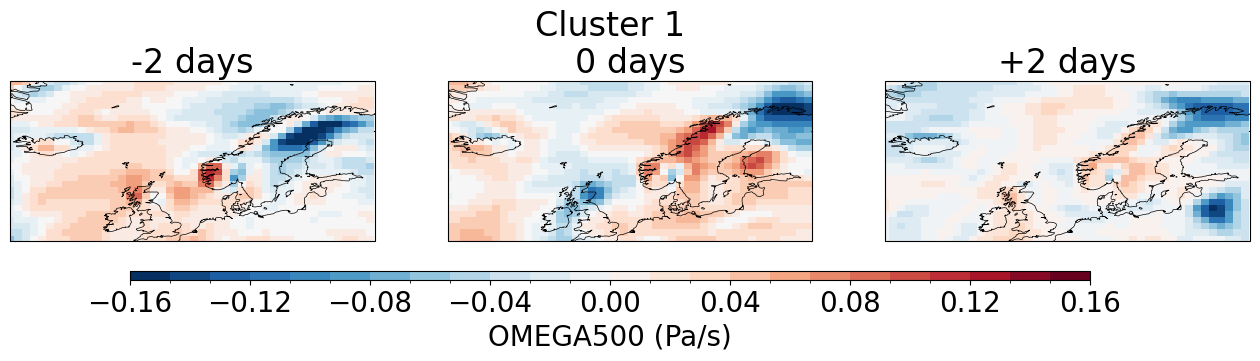

In [22]:
#testing for one cluster
fig, axs = plt.subplots(nrows=1,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(16,3)
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()#Loop over all of the models

fg = (cluster_data[0]['OMEGA500']).isel(time=12).mean(dim='member').plot(ax=axs[0],cmap='RdBu_r',add_colorbar=False,levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[0].add_patch(circle2)
axs[0].set_title(f'-2 days')
axs[0].coastlines(linewidth=0.5)  # cartopy function


fg = (cluster_data[0]['OMEGA500']).isel(time=14).mean(dim='member').plot(ax=axs[1],cmap='RdBu_r',levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
axs[1].set_title(f'0 days')
axs[1].coastlines(linewidth=0.5)  # cartopy function


fg = (cluster_data[0]['OMEGA500']).isel(time=16).mean(dim='member').plot(ax=axs[2],cmap='RdBu_r',add_colorbar=False,levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[5].add_patch(circle4)
axs[2].set_title(f'+2 days')
axs[2].coastlines(linewidth=0.5)  # cartopy function

cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.03])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='OMEGA500 (Pa/s)')
cbar.set_ticks(np.arange(-0.16,0.17,0.04))


plt.suptitle(f'Cluster 1',y=1)
#fig.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
    #fig.savefig(f'{out_plots}/{fig_labs[n]}_event_summary.pdf', format='pdf', bbox_inches='tight')

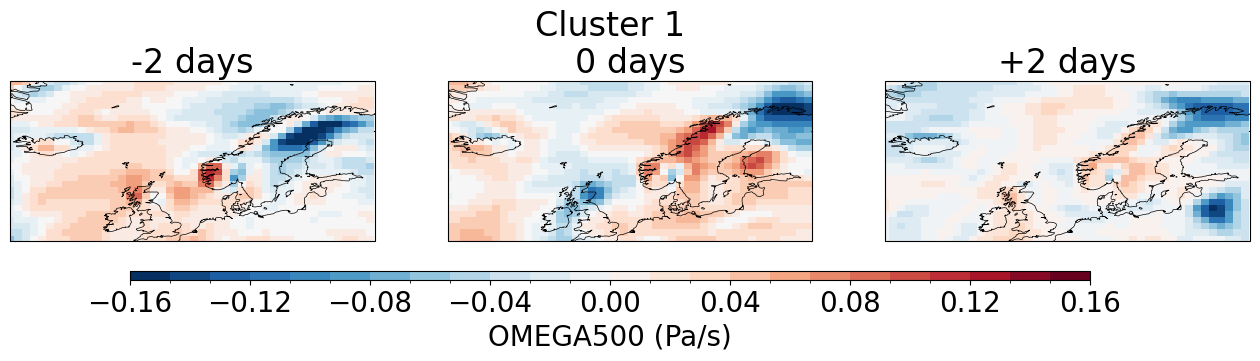

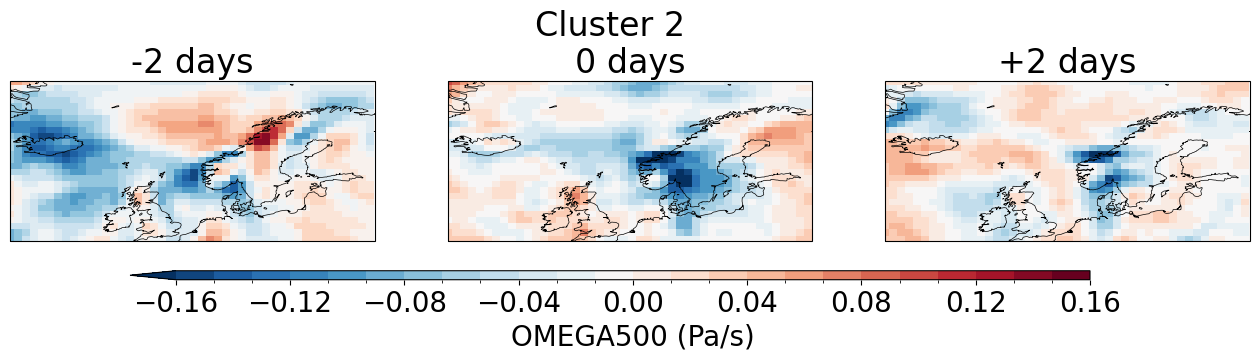

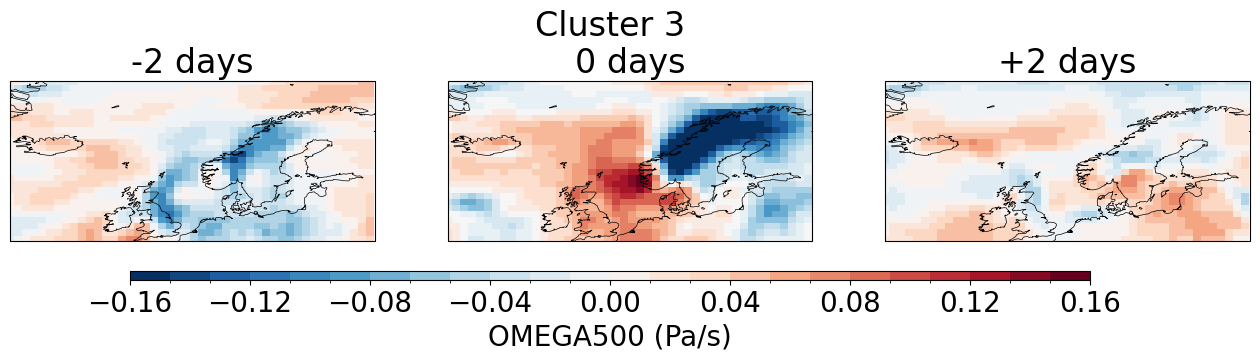

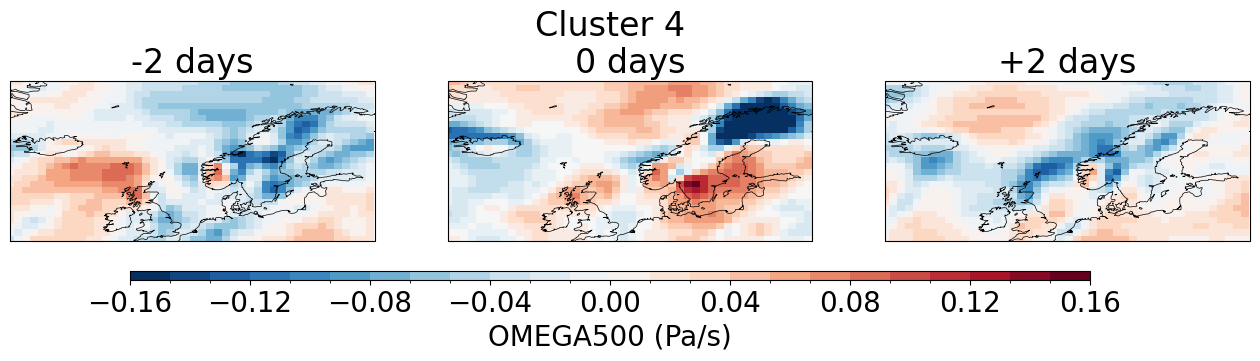

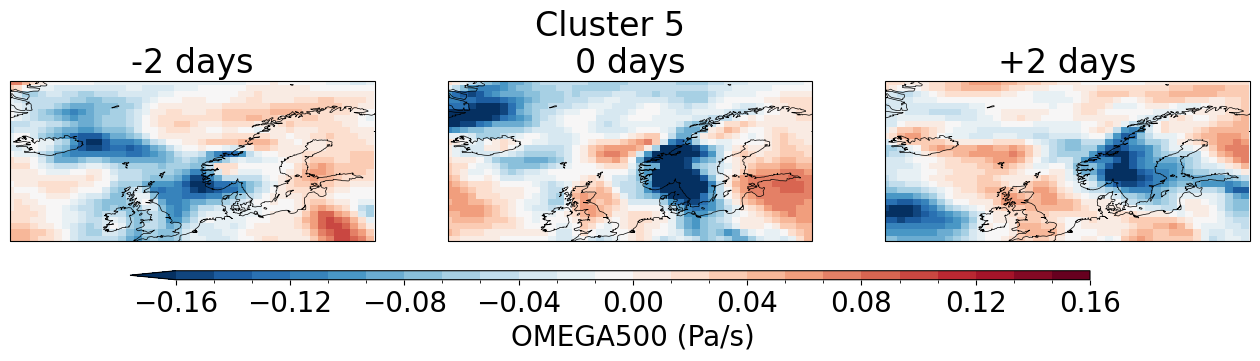

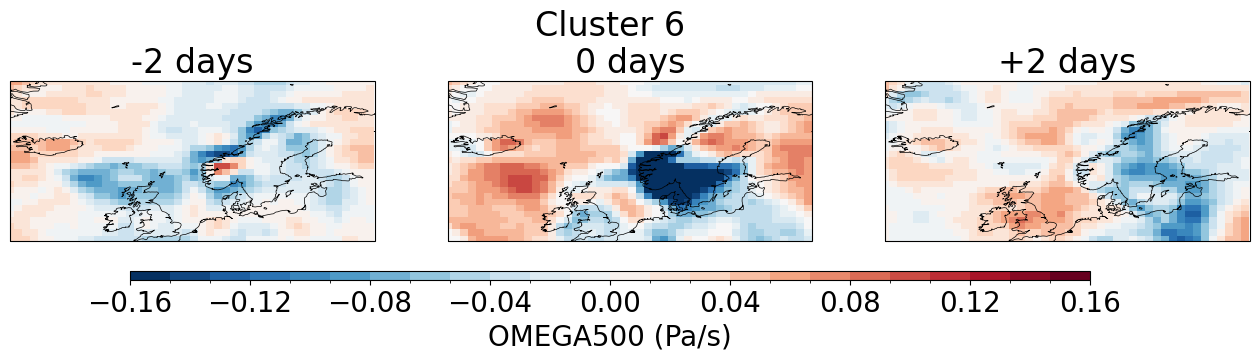

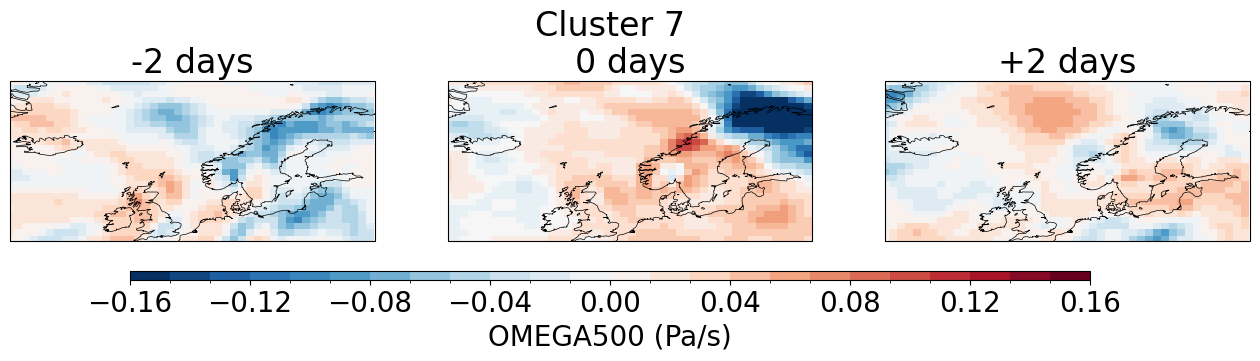

In [23]:
for n,time in enumerate(cluster_data):
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=1,ncols=3,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(16,3)
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()#Loop over all of the models

    fg = (cluster_data[n]['OMEGA500']).isel(time=12).mean(dim='member').plot(ax=axs[0],cmap='RdBu_r',add_colorbar=False,levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[0].add_patch(circle2)
    axs[0].set_title(f'-2 days')
    axs[0].coastlines(linewidth=0.5)  # cartopy function


    fg = (cluster_data[n]['OMEGA500']).isel(time=14).mean(dim='member').plot(ax=axs[1],cmap='RdBu_r',levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
    axs[1].set_title(f'0 days')
    axs[1].coastlines(linewidth=0.5)  # cartopy function


    fg = (cluster_data[n]['OMEGA500']).isel(time=16).mean(dim='member').plot(ax=axs[2],cmap='RdBu_r',add_colorbar=False,levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[5].add_patch(circle4)
    axs[2].set_title(f'+2 days')
    axs[2].coastlines(linewidth=0.5)  # cartopy function

    cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.03])
    cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='OMEGA500 (Pa/s)')
    cbar.set_ticks(np.arange(-0.16,0.17,0.04))

    plt.suptitle(f'Cluster {n+1}',y=1)
#fig.subplots_adjust(bottom=0.2, top=0.95, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
    #fig.savefig(f'{out_plots}/{fig_labs[n]}_event_summary.pdf', format='pdf', bbox_inches='tight')

/scratch/tmp/ipykernel_3949494/179344649.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1)


Text(0.07, 0.225, 'OMEGA500 (Pa/s)')

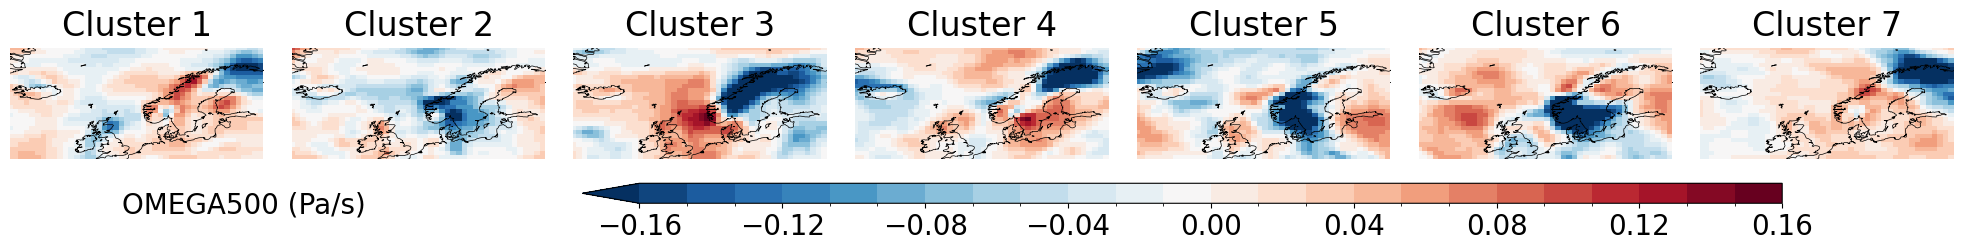

In [20]:
fig, axs = plt.subplots(nrows=1,ncols=len(cluster_data),
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(20,4),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    fg = (cluster_data[n]['OMEGA500']).isel(time=14).mean(dim='member').plot(ax=axs[n],cmap='RdBu_r',levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
    axs[n].set_title(f'0 days')
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title(f'Cluster {n+1}',y=1.03)


cbar_ax = fig.add_axes([0.3, 0.25, 0.6, 0.05])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='')
cbar.set_ticks(np.arange(-0.16,0.17,0.04))
#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=1)
fig.text(0.07,0.225,f'OMEGA500 (Pa/s)')

/scratch/tmp/ipykernel_3949494/419781767.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


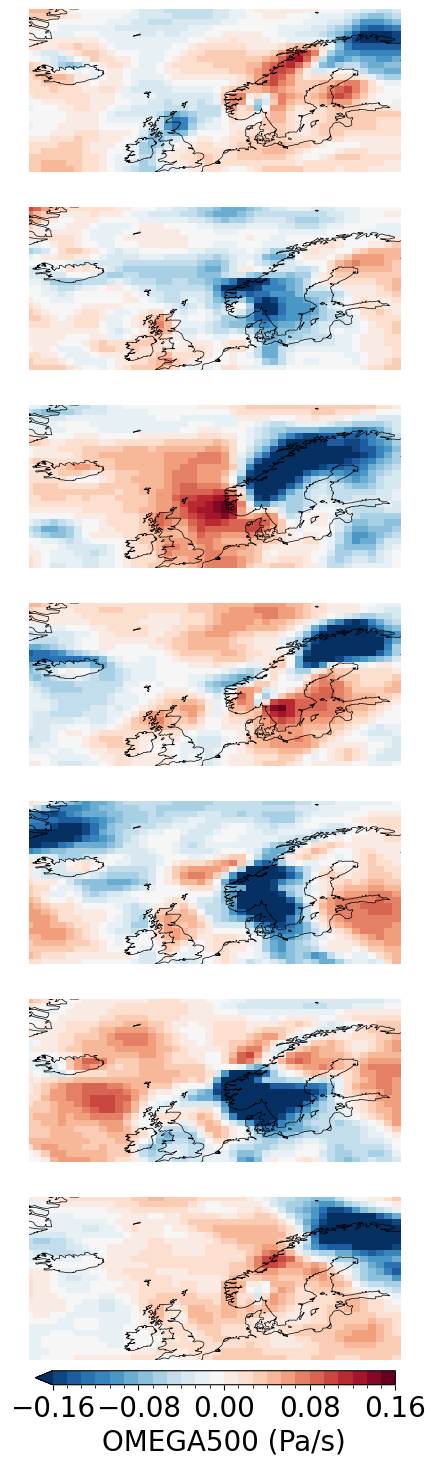

In [18]:
fig, axs = plt.subplots(nrows=len(cluster_data),ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree(),'frameon':False},
                        figsize=(4,14),
                        frameon=False
                        )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the models
for n,time in enumerate(cluster_data):
    fg = (cluster_data[n]['OMEGA500']).isel(time=14).mean(dim='member').plot(ax=axs[n],cmap='RdBu_r',levels=25,#,norm=norm, #
                                                vmax=0.16, vmin=-0.16, 
                                                add_colorbar=False,
        #cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[4].add_patch(circle3)
    #axs[n].set_title(f'0 days')
    axs[n].coastlines(linewidth=0.5)  # cartopy function
    axs[n].set_title('')#(f'Cluster {n+1}',y=1.03)


cbar_ax = fig.add_axes([0.05, 0.0, 0.9, 0.01])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='OMEGA500 (Pa/s)')
cbar.set_ticks(np.arange(-0.16,0.17,0.08))
#cbar_ax = fig.add_axes([0.2, 0.47, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')
#plt.suptitle(f'Locations of grouped {exp_label} extremes',y=0.88)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.17)
plt.tight_layout(pad=0.5)
#fig.text(0.07,0.225,f'OMEGA500 (Pa/s)')